In [16]:
import oracledb
import pandas as pd
import matplotlib.pyplot as plt
try:
    conn = oracledb.connect(
        user = 'hr',
        password = 'basededatos',
        dsn = 'localhost:1521/XE'
    )
    cursor = conn.cursor()
except oracledb.Error as e:
    print(e)

# Practica de subqueries

1. Se desea hacer una promoción especial de los artículos más caros (aquellos cuyo precio supera los 10 euros). Mostrar el código, descripción, precio original y precio de promoción de los artículos. El precio de promoción se calcula de la siguiente forma: Si el precio es menor de 20 euros, se aplica un 10% de descuento en la promoción. Si es menor de 30 euros, se aplica un 20%. Si es menor de 40 euros se aplica un 30%, si supera los 40 euros, se aplica un 40%

In [120]:
cursor.execute(
"""
SELECT art_codigo, art_descripcion, art_precio, 
    CASE
        WHEN art_precio < 20 THEN art_precio * 0.9
        WHEN art_precio < 30 THEN art_precio * 0.8
        WHEN art_precio < 40 THEN art_precio * 0.7
        ELSE art_precio * 0.6
    END AS "Precio promocion"
FROM articulo
WHERE art_precio > 10
ORDER BY art_precio DESC
"""
)
resultado = cursor.fetchall()
columnas = ['Codigo', 'Descripcion', 'Precio', 'Precio_promocion']
df = pd.DataFrame(resultado, columns=columnas)
print(df)

   Codigo              Descripcion  Precio  Precio_promocion
0   A0010           Portátil Basic     350             210.0
1   A0007   Impresora Multifunción     150              90.0
2   A0001  Monitor LED 24 Pulgadas     120              72.0
3   A0011       Tablet 10 Pulgadas     110              66.0
4   A0006         Silla de Oficina      95              57.0
5   A0008            Disco SSD 1TB      92              55.2
6   A0015     Smartwatch Deportivo      85              51.0
7   A0014            Router WiFi 6      45              27.0
8   A0005                Webcam HD      35              24.5
9   A0013      Altavoces Bluetooth      28              22.4
10  A0004       Auriculares Gaming      25              20.0
11  A0002      Teclado Inalámbrico      19              17.1
12  A0012           Funda Portátil      15              13.5


Ahora mostremos en un grafico los productos y sus precios


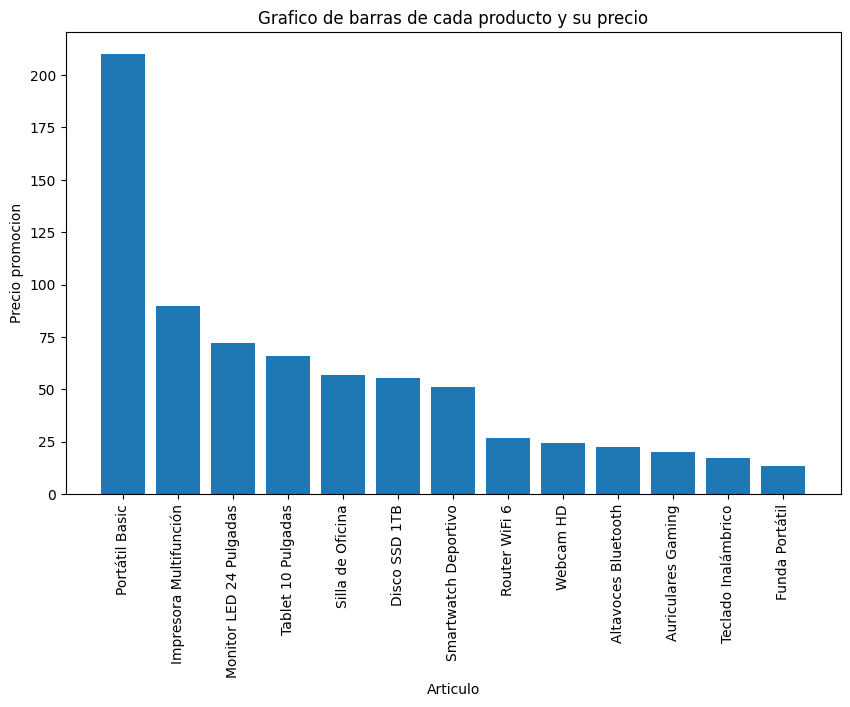

In [121]:
print('Ahora mostremos en un grafico los productos y sus precios')
#Haremos un grafico de barras
plt.figure(figsize=(10,6))
plt.title('Grafico de barras de cada producto y su precio')
plt.bar(df.Descripcion, df.Precio_promocion)
plt.xlabel('Articulo')
plt.ylabel('Precio promocion')
plt.xticks(rotation=90)
plt.show()

2. Listar el código, fecha y código de cliente de las facturas de los diez primeros días del mes de febrero del año pasado (independiente de cual sea este año)

In [122]:
cursor.execute(
"""
SELECT fac_codigo, fac_fecha, cli_codigo FROM factura
WHERE TO_CHAR(fac_fecha, 'MM') = '02'
AND TO_NUMBER(TO_CHAR(fac_fecha, 'DD')) <= 10
AND TO_NUMBER(TO_CHAR(fac_fecha, 'YYYY')) = (TO_NUMBER(TO_CHAR(SYSDATE, 'YYYY'))-1)
"""
)
resultado = cursor.fetchall()
columnas = ['Codigo_factura', 'Fecha_factura', 'Codigo_cliente']
df = pd.DataFrame(resultado, columns=columnas)
print(df)

   Codigo_factura Fecha_factura  Codigo_cliente
0               4    2025-02-02               6
1              14    2025-02-05               1
2              20    2025-02-08              19
3              23    2025-02-01              18
4              25    2025-02-05              13
5              28    2025-02-09               3


3. Escribir una consulta que muestre el código y la descripción de los artículos cuyo precio es mayor de 90,15 euros y se hayan vendido menos de 10 unidades (o ninguna) durante el año pasado (independiente del año actual)
Ayuda: la subconsulta debe calcular las ventas para el artículo actual

In [123]:
cursor.execute(
"""
SELECT a.art_codigo, a.art_descripcion
FROM articulo a
WHERE a.art_precio > 90.15
AND (
    SELECT NVL(SUM(l.lin_cantidad), 0)
    FROM linea_factura l
    JOIN factura f ON l.fac_codigo = f.fac_codigo
    WHERE l.art_codigo = a.art_codigo
    AND TO_NUMBER(TO_CHAR(f.fac_fecha, 'YYYY')) = (TO_NUMBER(TO_CHAR(SYSDATE, 'YYYY')) - 1)
) < 10
"""
)
resultado = cursor.fetchall()
columnas = ['Codigo', 'Descripcion']
df = pd.DataFrame(resultado, columns=columnas)
print(df)

  Codigo              Descripcion
0  A0001  Monitor LED 24 Pulgadas
1  A0006         Silla de Oficina
2  A0008            Disco SSD 1TB


Ahora hagamos un grafico


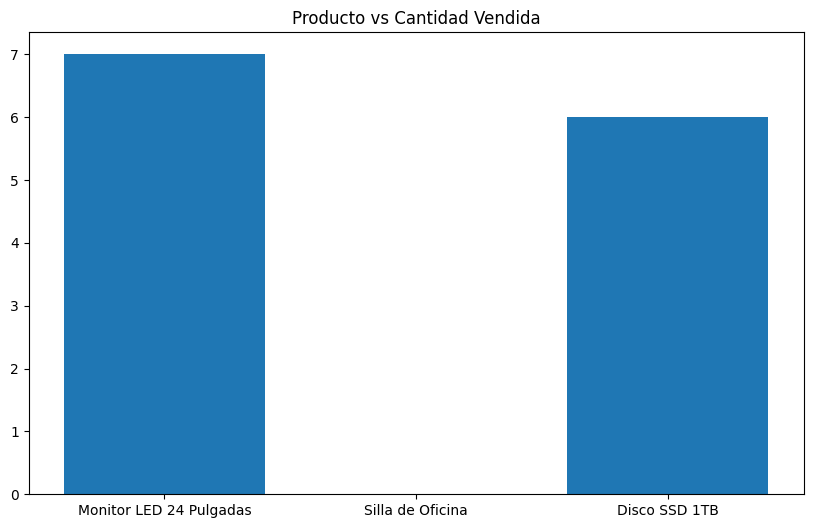

In [124]:
print('Ahora hagamos un grafico')
cursor.execute(
"""
SELECT a.art_descripcion, (
    SELECT NVL(SUM(l.lin_cantidad), 0) FROM linea_factura l
    JOIN factura f ON l.fac_codigo = f.fac_codigo
    WHERE l.art_codigo = a.art_codigo
    AND TO_NUMBER(TO_CHAR(f.fac_fecha, 'YYYY')) = TO_NUMBER(TO_CHAR(SYSDATE, 'YYYY')) - 1
) AS "Cantidad_vendida"
FROM articulo a
WHERE a.art_precio > 90.15
AND (
    SELECT NVL(SUM(l.lin_cantidad), 0)
    FROM linea_factura l
    JOIN factura f ON l.fac_codigo = f.fac_codigo
    WHERE l.art_codigo = a.art_codigo
      AND TO_NUMBER(TO_CHAR(f.fac_fecha, 'YYYY')) = TO_NUMBER(TO_CHAR(SYSDATE, 'YYYY')) - 1
) < 10
"""
)
resultado = cursor.fetchall()
columnas = ['Producto', 'Cantidad_vendida']
df = pd.DataFrame(resultado, columns=columnas)
plt.figure(figsize=(10,6))
plt.title('Producto vs Cantidad Vendida')
#Grafico de barras
plt.bar(df.Producto, df.Cantidad_vendida)

#Grafico de pastel
#plt.pie(df.Cantidad_vendida, labels=df.Producto, autopct='%1.1f')
plt.show()

4. Escribir una consulta que muestre el número de artículos con un precio superior al 55% del precio máximo de los artículos
Ayuda: uso de una subconsulta para calcular el precio máximo de los artículos

In [125]:
cursor.execute(
"""
SELECT COUNT(art_codigo) FROM articulo
WHERE art_precio > (
    SELECT MAX(art_precio)*0.55 FROM articulo
)
"""
)
resultado = cursor.fetchall()
columnas = ['Numero de articulos']
df = pd.DataFrame(resultado, columns=columnas)
print(df)

   Numero de articulos
0                    1


Grafiquemos los articulos que tienen un precio mayor al 20% del precio maximo


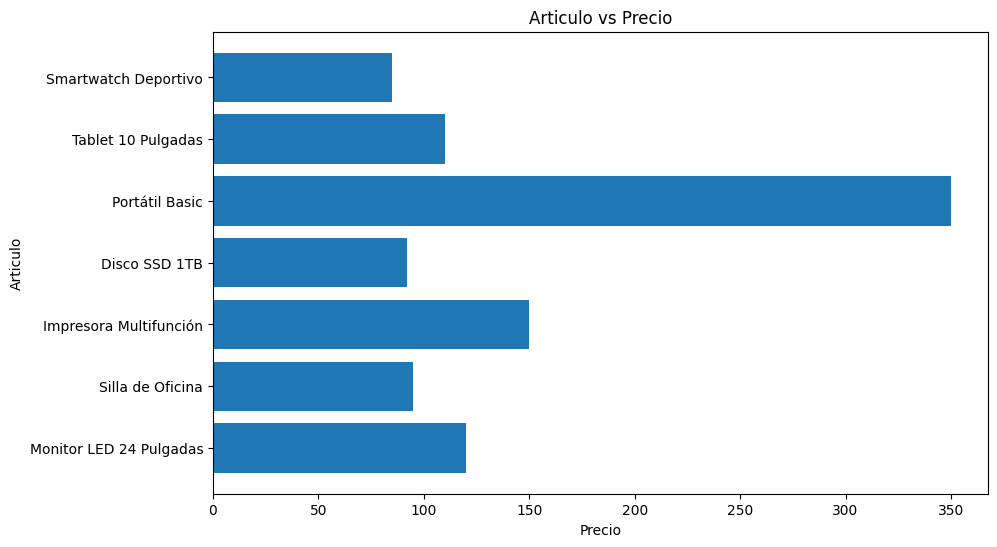

In [126]:
print('Grafiquemos los articulos que tienen un precio mayor al 20% del precio maximo')
cursor.execute(
"""
SELECT art_descripcion, art_precio FROM articulo
WHERE art_precio > (
    SELECT MAX(art_precio)*0.20 FROM articulo
)
"""
)
resultado = cursor.fetchall()
columnas = ['Articulo', 'Precio']
df = pd.DataFrame(resultado, columns=columnas)
plt.figure(figsize=(10,6))
plt.title('Articulo vs Precio')
#grafico de lineas HORIZONTAL
# plt.plot(df.Precio, df.Articulo)
# plt.xlabel(columnas[1])
# plt.ylabel(columnas[0])

#Grafico de barras horizontal
plt.barh(df.Articulo, df.Precio)
plt.xlabel(columnas[1])
plt.ylabel(columnas[0]) #iguales al de lineas

#grafico de pastel
#plt.pie(df.Precio, labels=df.Articulo, autopct='%1.1f')



plt.show()


5. Escribir una sentencia que calcule el número de facturas sin descuento (cero o nulo); con descuento moderado (<= 10) y con descuento elevado

In [127]:
cursor.execute(
"""
SELECT 
    COUNT(CASE WHEN fac_dcto IS NULL OR fac_dcto = 0 THEN 1 END) AS "Sin descuento",
    COUNT(CASE WHEN fac_dcto > 0 AND fac_dcto <= 10 THEN 1 END) AS "Descuento moderado",
    COUNT(CASE WHEN fac_dcto > 10 THEN 1 END) AS "Descuento elevado"
FROM factura
"""
)
resultado = cursor.fetchall()
columnas = ['Sin_descuento', 'Descuento_moderado', 'Descuento_elevado']
df = pd.DataFrame(resultado, columns=columnas)
print(df)

   Sin_descuento  Descuento_moderado  Descuento_elevado
0             12                  11                  5


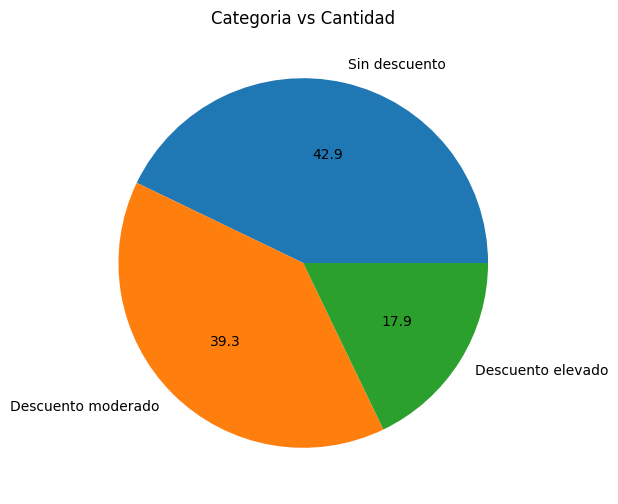

In [128]:
cursor.execute(
"""
SELECT 
    CASE 
        WHEN fac_dcto IS NULL OR fac_dcto = 0 THEN 'Sin descuento'
        WHEN fac_dcto > 0 AND fac_dcto <= 10 THEN 'Descuento moderado'
        ELSE 'Descuento elevado'
    END AS Categoria,
    COUNT(*) AS Cantidad
FROM factura
GROUP BY 
    CASE 
        WHEN fac_dcto IS NULL OR fac_dcto = 0 THEN 'Sin descuento'
        WHEN fac_dcto > 0 AND fac_dcto <= 10 THEN 'Descuento moderado'
        ELSE 'Descuento elevado'
    END
"""
)
resultado = cursor.fetchall()
columnas = ['Categoria', 'Cantidad']
df = pd.DataFrame(resultado, columns=columnas)
plt.figure(figsize=(10,6))
plt.title('Categoria vs Cantidad')
#Grafico de barras
# plt.bar(df.Categoria, df.Cantidad)
# plt.xlabel(columnas[0])
# plt.ylabel(columnas[1])

#grafico de pastel
plt.pie(df.Cantidad, labels=df.Categoria, autopct='%1.1f')

#grafico de lineas
#plt.plot(df.Categoria, df.Cantidad)

plt.show()




6. Escribir una consulta que muestre el número de artículos con un precio superior al 55% del precio máximo de los artículos
Ayuda: uso de una subconsulta para calcular el precio máximo de los artículos

In [129]:
cursor.execute(
"""
SELECT COUNT(art_codigo) FROM articulo
WHERE art_precio > (
    SELECT MAX(art_precio)*0.55 FROM articulo
)
"""
)
resultado = cursor.fetchall()
columnas = ['Numero de articulos']
df = pd.DataFrame(resultado, columns=columnas)
print(df)

   Numero de articulos
0                    1


7. Escribir una consulta que muestre el nombre del cliente con mayor facturación
Ayuda: la subconsulta debe calcular la mayor facturación realizada por un cliente

In [130]:
cursor.execute(
"""
SELECT cli_nombre FROM cliente
WHERE cli_codigo = (
    SELECT cli_codigo FROM (
        SELECT f.cli_codigo, SUM(l.lin_cantidad * l.lin_precio) AS TOTAL_DINERO 
        FROM factura f
        JOIN linea_factura l ON f.fac_codigo = l.fac_codigo
        GROUP BY f.cli_codigo
        ORDER BY TOTAL_DINERO DESC
    )
    WHERE ROWNUM = 1
)
"""
)
resultado = cursor.fetchall()
columnas = ['Nombre']
df = pd.DataFrame(resultado, columns=columnas)
print(df)

                Nombre
0  Manuel Martin Gomez


Graficaremos los 5 que mas facturan


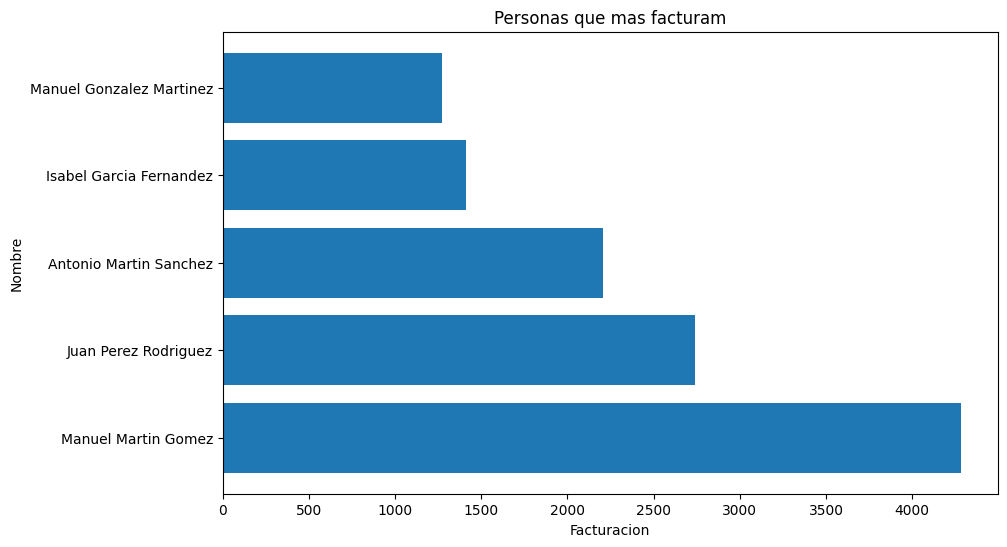

In [131]:
print('Graficaremos los 5 que mas facturan')
cursor.execute(
"""
SELECT c.cli_nombre, tabla.TOTAL_DINERO FROM (
    SELECT f.cli_codigo, SUM(l.lin_cantidad * l.lin_precio) AS TOTAL_DINERO FROM factura f
    JOIN linea_factura l ON f.fac_codigo = l.fac_codigo
    GROUP BY f.cli_codigo
    ORDER BY TOTAL_DINERO DESC
) tabla
JOIN cliente c ON tabla.cli_codigo = c.cli_codigo
WHERE ROWNUM <= 5
"""
)
resultado = cursor.fetchall()
columnas = ['Nombre', 'Facturacion']
df = pd.DataFrame(resultado, columns=columnas)
plt.figure(figsize=(10,6))
plt.title('Personas que mas facturam')
#Grafico de barras horizontal
plt.barh(df.Nombre, df.Facturacion)
plt.xlabel(columnas[1])
plt.ylabel(columnas[0])

plt.show()

8. Escribir una consulta que obtenga el máximo descuento aplicado cada año, considerando el descuento nulo como cero
Ayuda: agrupación por fecha

In [132]:
cursor.execute(
"""
SELECT TO_CHAR(fac_fecha,'YYYY'), MAX(fac_dcto) FROM factura
GROUP BY TO_CHAR(fac_fecha,'YYYY')
ORDER BY TO_CHAR(fac_fecha,'YYYY')
"""
)
resultado = cursor.fetchall()
columnas = ['Año', 'Descuento_Maximo']
df = pd.DataFrame(resultado, columns=columnas)
print(df)

    Año  Descuento_Maximo
0  2024                10
1  2025                15
2  2026                15


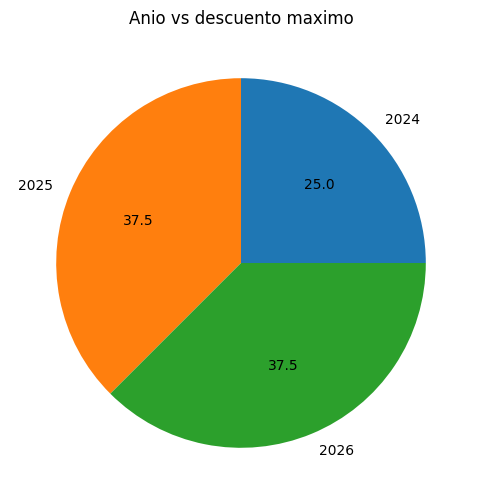

In [133]:
plt.figure(figsize=(10,6))
plt.title('Anio vs descuento maximo')
#grafico de pastel
plt.pie(df.Descuento_Maximo, labels=df.Año, autopct='%1.1f')
plt.show()

In [13]:
cursor.execute(
"""
UPDATE employees e
SET salary = (
    CASE
        WHEN (SELECT AVG(e1.salary) FROM employees e1 WHERE e1.department_id = e.department_id) > 8000 
        THEN (SELECT AVG(e1.salary) FROM employees e1 WHERE e1.department_id = e.department_id) * 0.9
        ELSE (SELECT AVG(e1.salary) FROM employees e1 WHERE e1.department_id = e.department_id) * 1.1
    END
)
WHERE salary < (SELECT AVG(e1.salary) FROM employees e1 WHERE e1.department_id = e.department_id)
"""
)
resultado = cursor.rowcount
print('Se actualizaron ', resultado, ' filas')

Se actualizaron  22  filas


In [20]:
cursor.execute(
"""
UPDATE employees e
SET department_id = (
    CASE
        WHEN manager_id = 100 THEN 1
        WHEN manager_id = 101 THEN 2
        WHEN manager_id = 102 THEN 3
        ELSE department_id
    END
)
"""
)
resultado = cursor.rowcount
print('Se actualizaron ', resultado, ' filas')

Se actualizaron  40  filas


In [22]:
cursor.execute(
"""
SELECT d.department_name, l.city, COUNT(e.employee_id) AS "Numero de empleados" FROM departments d
LEFT JOIN employees e ON d.department_id = e.department_id
LEFT JOIN locations l ON d.location_id = l.location_id
GROUP BY (d.department_name, l.city)
ORDER BY COUNT(e.employee_id) DESC
"""
)
resultado = cursor.fetchall()
columnas = ['Nombre', 'Ciudad', 'Numero de empleados']
df = pd.DataFrame(resultado, columns=columnas)
print(df)

              Nombre               Ciudad  Numero de empleados
0     Administration              Seattle                   14
1          Marketing              Toronto                    6
2         Purchasing              Seattle                    6
3            Finance              Seattle                    5
4                 IT            Southlake                    4
5           Shipping  South San Francisco                    3
6          Executive              Seattle                    1
7         Accounting              Seattle                    1
8   Public Relations               Munich                    0
9    Human Resources               London                    0
10             Sales               Oxford                    0
